In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import pandas as pd
import csv
mpl.rcParams.update({
  "text.usetex": True,
  "font.family": "Helvetica",
    'font.size': 24,
})

In [2]:
tn_results = {
  0.6: [0.4684147425665175, 0.4067007247130059, 0.3478813224580095, 0.3051239257192964, 0.2716497651604236, 0.24431292326513626, 0.22142606919477104, 0.2018813973055691, 0.18496269211546867, 0.17022892608137008, 0.15730254465022664, 0.14582685642027204, 0.13566405159409217, 0.12664611865555925, 0.11852843425550236, 0.11125179432461485],
  0.8: [0.7268494147341766, 0.5931645477318571, 0.4684404847996838, 0.38045441464739976, 0.3141017317836666, 0.26237704308001797, 0.2212427938144037, 0.18805025394602015, 0.16097474070420037, 0.13865581896347867, 0.12014179795193536, 0.104703608436291, 0.09175695403524176, 0.08084127784878914, 0.07160662733162315, 0.06373678241981717],
}

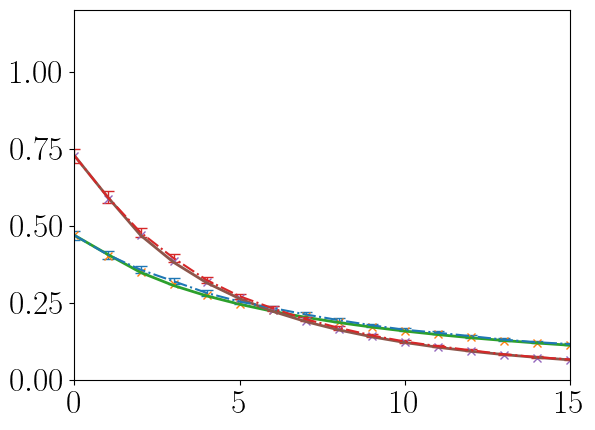

In [3]:
A = np.loadtxt('data/results_TF_fig1_b.txt')

df = pd.DataFrame(A,columns=['nn','L','NA','time','th','tra','traq','enta','entaq'])
df['P_AQ'] = np.log(df['tra'].values /  df['traq'].values)
df['EA'] = -np.log(df['tra'].values)
df['EAQ'] = -np.log(df['traq'].values)

dfe = df.groupby(by=['time','NA','L','th'],).std()
dfe = dfe.reset_index()
df = df.groupby(by=['time','NA','L','th'],as_index=False).mean()

for th in [0.6,0.8,]:
  dfx = df[np.isclose(df.th,th)]
  dfxe = df[np.isclose(dfe.th,th)]

  plt.errorbar(dfx.time,dfx['P_AQ'],yerr=dfxe['P_AQ']/np.sqrt(1000),elinewidth=1,capsize=4,fmt='-.')
  plt.plot(dfx.time,-np.log(dfx.traq)+np.log(dfx.tra),'x') 

  plt.plot(tn_results[th],lw=2)

  plt.ylim(0,1.2)
  plt.xlim(0,15)
plt.xlabel('time')
plt.ylabel()

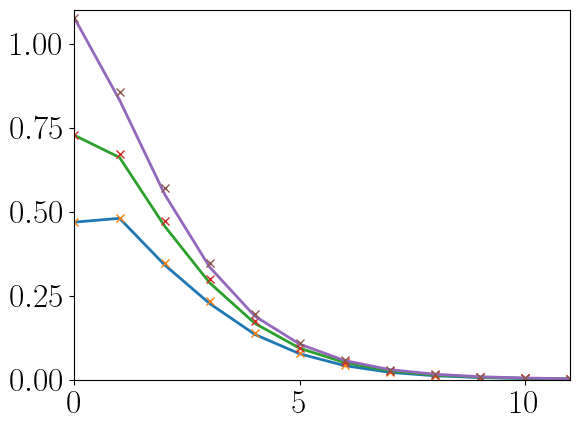

In [33]:
A = np.loadtxt('results_TAF_fig1_b.txt')
df = pd.DataFrame(A,columns=['nn','L','NA','time','th','tra','traq','enta','entaq'])
# print(df.nn.values)
df['P_AQ'] = np.log(df['tra'].values /  df['traq'].values)
df['EA'] = -np.log(df['tra'].values)
df['EAQ'] = -np.log(df['traq'].values)

dfe = df.groupby(by=['time','NA','L','th'],).std()
dfe = dfe.reset_index()
df = df.groupby(by=['time','NA','L','th'],as_index=False).mean()

for th in [0.6,0.8,1.2]:
  dfx = df[np.isclose(df.th,th)]

  plt.plot(dfx.time,dfx['P_AQ'],'-',lw=2)

  plt.plot(dfx.time,-np.log(dfx.traq)+np.log(dfx.tra),'x',)

  plt.ylim(0,1.1)
  plt.xlim(0,11)

[ 0.26178393  4.18325222 17.12068966]
[0.24364448 1.54303398 6.8991453 ]
[2.47557082]
[2.28257488]
[2.19741836]
[2.12816268]


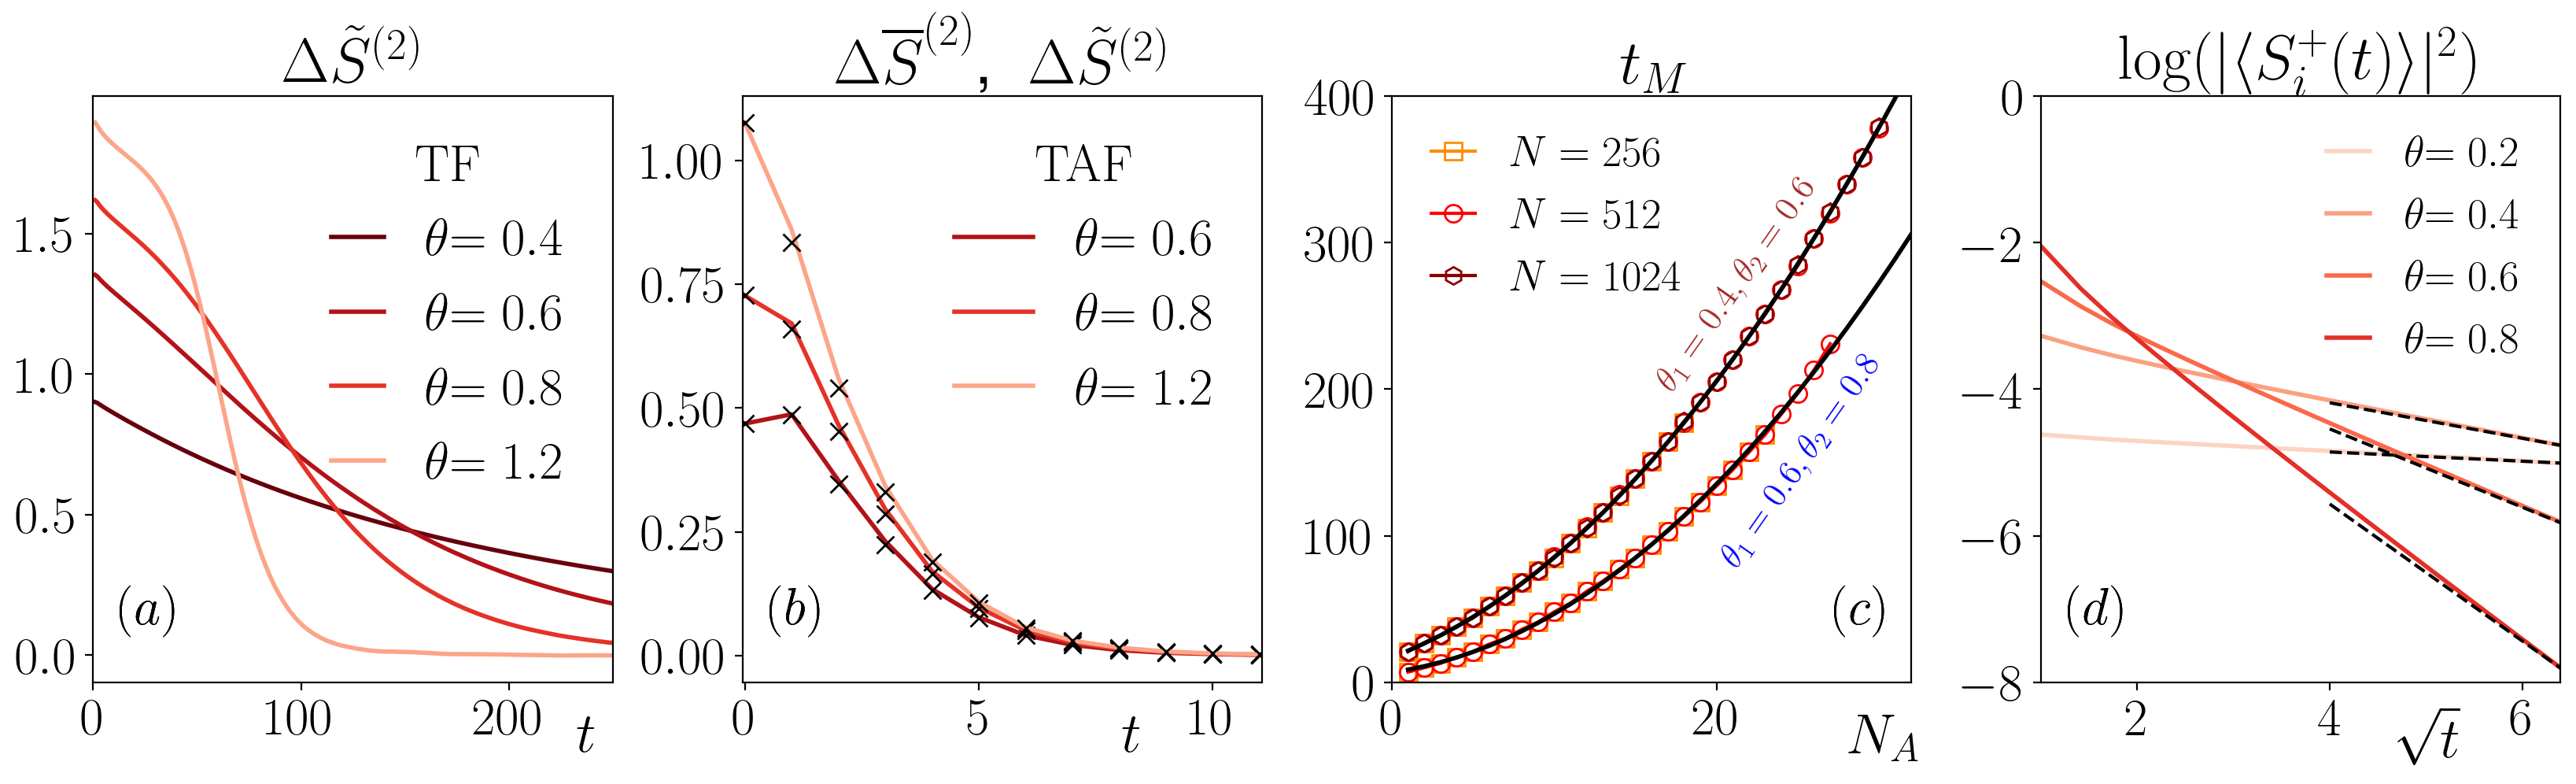

In [45]:
fig, axs = plt.subplots(1,4,dpi=200,figsize=(16,3.8),)
cm = mpl.cm.ScalarMappable(cmap='Reds_r',norm=mpl.colors.Normalize(vmin=0.4,vmax=np.pi/2))

ax = axs[0]
ax.set_title(r'$\Delta \tilde{S}^{(2)}$')

dfx = pd.read_csv(f'data/TN_TF_N{512}NA{16}.csv')
for th in [0.4,0.6,0.8,1.2]:
  dff = dfx[np.isclose(dfx.th,th)]
  x = dff.time
  y = (dff.EAQ - dff.EA)
  ax.plot(x,y,lw=2,c=cm.to_rgba(th),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={th}$')
ax.set_xlabel(r'$t$')
ax.legend(frameon=False,handlelength=1.,title=r'$\mathrm{TF}$')


ax = axs[1]
df = pd.read_csv('data/ED_TAF_N20NA3.csv')
for th in [0.6,0.8,1.2,]:
  dfx = df[np.isclose(df.th,th)]
  y1 = dfx.P_AQ.values 
  y2 = (dfx.EA.values - dfx.EAQ.values)
  x = dfx.time.values 
  ax.plot(x,y2,c=cm.to_rgba(th),marker='h',mec='k',ms=0,ls='-',lw=2,label=r'$\theta$'+f'$={th}$')
  ax.plot(x,y1,c=cm.to_rgba(th),marker='x',mec='k',ms=8,lw=0)
  ax.set_xlim(0,11.5)
ax.legend(frameon=False,handlelength=1.5,title=r'$\mathrm{TAF}$')
ax.set_title(r'$\Delta \overline{S}^{(2)}$,\; $\Delta \tilde{S}^{(2)}$')

ax = axs[2]

tau_mpemba0608 = {}

with open('data/delta_theta0608.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        key = int(row[0])  # first item is the dictionary key
        values = list(map(int, row[1:]))  # the rest are the list values
        tau_mpemba0608[key] = values

tau_mpemba0406 = {}

with open('data/delta_theta0406.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        key = int(row[0])  # first item is the dictionary key
        values = list(map(int, row[1:]))  # the rest are the list values
        tau_mpemba0406[key] = values


for mk,L,color in zip(['s','o','h','^'],[256,512,1024],['darkorange','red','darkred']):
  ax.plot((np.arange(1,len(tau_mpemba0406[L])+1)),(tau_mpemba0406[L]),'-',c=color,ms=8,marker=mk,mfc='None',label=f'$N={L}$')
pop = np.polyfit((np.arange(1,len(tau_mpemba0406[1024])+1)),(tau_mpemba0406[1024]),deg=2,)
xx = np.arange(1,33)
yy = np.polyval(pop,xx)
ax.plot(xx,yy,c='k',lw=2)

print(pop)
for mk,L,color in zip(['s','o','h','^'],[256,512,],['darkorange','red','darkred']):
  ax.plot((np.arange(1,len(tau_mpemba0608[L])+1)),(tau_mpemba0608[L]),'-',c=color,ms=8,marker=mk,mfc='None',) #label=f'$N={L}$')
pop = np.polyfit((np.arange(1,len(tau_mpemba0608[512])+1)),(tau_mpemba0608[512]),deg=2,)
xx = np.arange(1,33)
yy = np.polyval(pop,xx)
ax.plot(xx,yy,c='k',lw=2)
print(pop)


an1 = ax.annotate(r'$ {\theta_1 = 0.4}, {\theta_2 = 0.6}$',fontsize=16,xy=(16, 200),rotation=55,transform=ax.transAxes,c='brown')
an2 = ax.annotate(r'$ {\theta_1 = 0.6}, {\theta_2 = 0.8}$',fontsize=16,xy=(20, 80),rotation=55,transform=ax.transAxes,c='blue')


for ax,let in zip(axs,[r'$(a)$',r'$(b)$',r'$(c)$',r'$(d)$']):
  ax.set_xlabel(r"$t$",fontsize=26)
  ax.xaxis.set_label_coords(0.75,-0.05,transform=ax.transAxes,)
  
  if  ax==axs[1]:
    ax.set_xlim(-.05,11.05)
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
  elif ax==axs[0]:
    ax.set_xlim(0,250)
    ax.xaxis.set_label_coords(0.95,-0.05,transform=ax.transAxes,)
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
  elif ax==axs[2]:
    # ax.set_xlim(0,36)
    # ax.set_ylim(0,25)
    ax.set_xlim(0,32)
    ax.set_ylim(0,400)
    
    ax.set_xlabel(r"$N_A$",fontsize=26)
    ax.set_title(r"${t_{M}}$")
    ax.text(0.85,0.1,let,transform=ax.transAxes,)
    ax.xaxis.set_label_coords(0.95,-0.05,transform=ax.transAxes,)
    ax.legend(frameon=False,ncol=1,columnspacing=0.5,handlelength=1,fontsize=20)
  else:
    ax.set_xlabel(r'$\sqrt{t}$')
    ax.set_title(r'$\log(|\langle S^+_i(t)\rangle|^2)$')
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
    ax.xaxis.set_label_coords(0.75,-0.05,transform=ax.transAxes,)

df = pd.read_csv('data/TN_OS_N80.csv')
cm = mpl.cm.ScalarMappable(cmap='Reds',norm=mpl.colors.Normalize(vmin=0,vmax=1.2))
from scipy.optimize import curve_fit 
for th in ["0.2","0.4","0.6","0.8",]:
  mm = len(x)
  tt = float(th)
  dfx= df[np.isclose(df.th,tt)]
  x = dfx.time.values 
  y = dfx.EV.values
  ff = lambda x,a : tt**2/4*np.exp(-np.sqrt(a*x)*(tt**2))
  pop, _ = curve_fit(ff,x[35:mm],y[35:mm],)
  print(pop)
  ax.plot(np.sqrt(x[:mm]),np.log(y[:mm]),lw=2,c=cm.to_rgba(float(th)),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={float(th)}$')

  ax.plot(np.sqrt(x[15:mm]),np.log(ff(x[15:mm],*pop)),c='k',ls='--')
  
  ax.legend(frameon=False,ncol=1,columnspacing=0.5,handlelength=1,fontsize=20)
  ax.set_ylim(-8,0)
  ax.set_xlim(1,6.4)


for ax,let in zip(axs,[r'$(a)$',r'$(b)$',r'$(c)$',r'$(d)$']):
  ax.set_xlabel(r"$t$",fontsize=26)
  ax.xaxis.set_label_coords(0.75,-0.05,transform=ax.transAxes,)
  
  if  ax==axs[1]:
    ax.set_xlim(-.05,11.05)
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
  elif ax==axs[0]:
    ax.set_xlim(0,250)
    ax.xaxis.set_label_coords(0.95,-0.05,transform=ax.transAxes,)
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
  elif ax==axs[2]:
    # ax.set_xlim(0,36)
    # ax.set_ylim(0,25)
    ax.set_xlim(0,32)
    ax.set_ylim(0,400)
    
    ax.set_xlabel(r"$N_A$",fontsize=26)
    ax.set_title(r"${t_{M}}$")
    ax.text(0.85,0.1,let,transform=ax.transAxes,)
    ax.xaxis.set_label_coords(0.95,-0.05,transform=ax.transAxes,)
    ax.legend(frameon=False,ncol=1,columnspacing=0.5,handlelength=1,fontsize=20)
  else:
    ax.set_xlabel(r'$\sqrt{t}$')
    ax.set_title(r'$\log(|\langle S^+_i(t)\rangle|^2)$')
    ax.text(0.05,0.1,let,transform=ax.transAxes,)
    ax.xaxis.set_label_coords(0.75,-0.05,transform=ax.transAxes,)


plt.subplots_adjust(left=0.01,right=0.99,top=0.99,bottom=0.01,wspace=0.25)

/var/folders/b8/r867116s44l4wb3bmgmxnlk80000gp/T/ipykernel_78410/2256300063.py:14: RuntimeWarning: invalid value encountered in log
  ax.plot((x[:40]),np.log(y[:40]),lw=2,c=cm.to_rgba(float(th)),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={float(th)}$')
/var/folders/b8/r867116s44l4wb3bmgmxnlk80000gp/T/ipykernel_78410/2256300063.py:27: RuntimeWarning: invalid value encountered in log
  ax.plot((x[:mm]),np.log(y[:mm]),lw=2,c=cm.to_rgba(float(th)),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={float(th)}$')


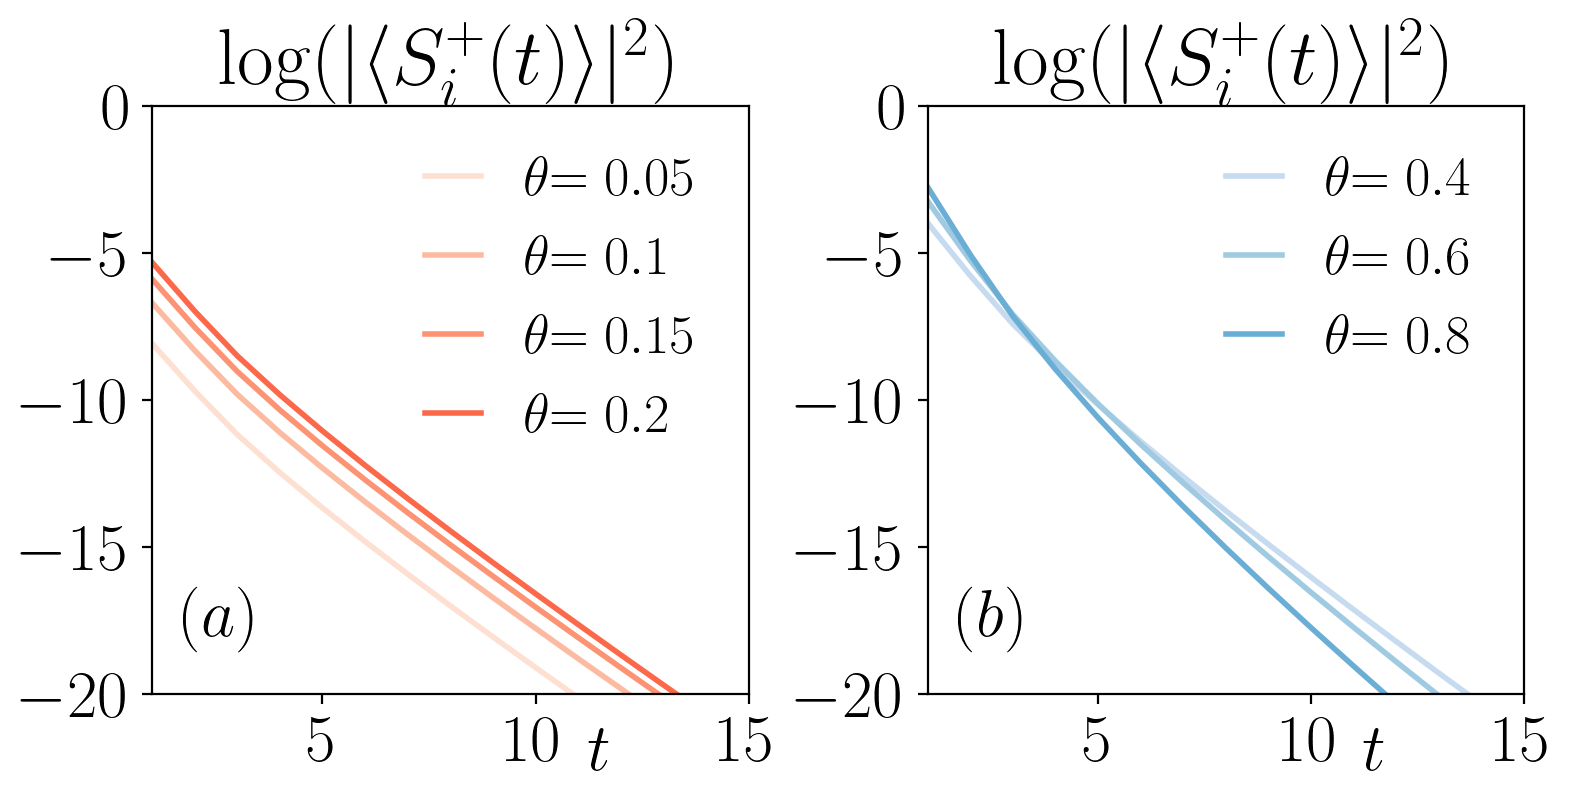

In [47]:
fig,axs = plt.subplots(1,2,dpi=200,figsize=(7,3))
cm = mpl.cm.ScalarMappable(cmap='Reds',norm=mpl.colors.Normalize(vmin=0,vmax=0.4))

df = pd.read_csv('data/TN_OS2_N80.csv')

ax = axs[0]

for th in ["0.05","0.1","0.15","0.2",]:
  mm = len(x)
  tt = float(th)
  dfx= df[np.isclose(df.th,tt)]
  x = dfx.time.values 
  y = dfx.EV.values
  ax.plot((x[:40]),np.log(y[:40]),lw=2,c=cm.to_rgba(float(th)),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={float(th)}$')  
  ax.legend(frameon=False,ncol=1,columnspacing=0.5,handlelength=1,fontsize=20)
  ax.set_ylim(-20,0)
  ax.set_xlim(1,15)

ax = axs[1]
cm = mpl.cm.ScalarMappable(cmap='Blues',norm=mpl.colors.Normalize(vmin=0,vmax=1.6))
for th in ["0.4","0.6","0.8",]:
  mm = len(x)
  tt = float(th)
  dfx= df[np.isclose(df.th,tt)]
  x = dfx.time.values 
  y = dfx.EV.values
  ax.plot((x[:mm]),np.log(y[:mm]),lw=2,c=cm.to_rgba(float(th)),mec='k',ms=0,marker='h',label=r'$\theta$'+f'$={float(th)}$')
  
  ax.legend(frameon=False,ncol=1,columnspacing=0.5,handlelength=1,fontsize=20)
  ax.set_ylim(-20,0)
  ax.set_xlim(1,15)
for ax in axs:
  ax.set_xlabel(r'$t$')
  ax.set_title(r'$\log(|\langle S^+_i(t)\rangle|^2)$')
  
  ax.xaxis.set_label_coords(0.75,-0.05,transform=ax.transAxes,)
axs[0].text(0.05,0.1,r'$(a)$',transform=axs[0].transAxes,)
axs[1].text(0.05,0.1,r'$(b)$',transform=axs[1].transAxes,)
plt.subplots_adjust(left=0.01,right=0.99,top=0.99,bottom=0.01,wspace=0.3)